In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
import ast
from sklearn.decomposition import PCA


df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'grouped'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'isolated'

df = pd.concat([df1, df2], ignore_index=True)  

interactions = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/cropped_interactions.csv')
cluster = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/F15_KMAX3_DMAX4_NMIN1500--/pca-data3-F15-mcmodels4-Kmax3-Dmax4-Nmin1500-05-2026.csv')


def anchor_partner(df):


        # make sure Interaction Pair is a real tuple
    df['Interaction Pair'] = df['Interaction Pair'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    # because (left,right) = (Track_1_id, Track_2_id)
    df['track1_id'] = df['Interaction Pair'].str[0]
    df['track2_id'] = df['Interaction Pair'].str[1]

    # prep columns
    df['anchor_track_id'] = np.nan
    df['partner_track_id'] = np.nan

    ## Returns a straightness score 
    def compute_pca_axis(points):
        pca = PCA(n_components=2).fit(points)
        axis = pca.components_[0]
        score = pca.explained_variance_ratio_[0]
        # ensure the axis points upward
        return (axis if axis[1] >= 0 else -axis), score
    
    ## == Align the tracks (anchor 0,0) and rotate partner accordingly (on the right)
    def align_and_flip(track, anchor_axis, anchor_start):
        X = track - anchor_start
        phi = np.arctan2(anchor_axis[1], anchor_axis[0])  # angle of axis
        alpha = np.pi/2 - phi                            # rotate to +y
        R = np.array([[np.cos(alpha), -np.sin(alpha)],
                    [np.sin(alpha),  np.cos(alpha)]])
        X_rot = X.dot(R.T)
        return X_rot
    
    df['anchor x_body'] = np.nan
    df['anchor y_body'] = np.nan
    df['partner x_body'] = np.nan
    df['partner y_body'] = np.nan

    ## == Generate the anchor and partner x,y coordinates for future

    for interaction_id, group in df.groupby('interaction_id'):
        group = group.sort_values('Frame')
        coords1 = group[['Track_1 x_body','Track_1 y_body']].values
        coords2 = group[['Track_2 x_body','Track_2 y_body']].values
        if len(coords1) < 2 or len(coords2) < 2:
            continue
        # Compute PCA axes & scores
        axis1, s1 = compute_pca_axis(coords1)
        axis2, s2 = compute_pca_axis(coords2)
        # Choose anchor and partner
        if s1 >= s2:
            winner = 1
            anchor_pts, partner_pts, anchor_axis = coords1, coords2, axis1
        else:
            winner = 2
            anchor_pts, partner_pts, anchor_axis = coords2, coords1, axis2

        # Align both
        start = anchor_pts[0]
        A_al = align_and_flip(anchor_pts, anchor_axis, start)
        B_al = align_and_flip(partner_pts, anchor_axis, start)

        # --- NEW: align head/tail using the SAME reference (before flips) ---
        h1 = group[['Track_1 x_head','Track_1 y_head']].dropna().values
        t1 = group[['Track_1 x_tail','Track_1 y_tail']].dropna().values
        h2 = group[['Track_2 x_head','Track_2 y_head']].dropna().values
        t2 = group[['Track_2 x_tail','Track_2 y_tail']].dropna().values

        A_head = align_and_flip(h1 if winner == 1 else h2, anchor_axis, start) if (len(h1) or len(h2)) else np.empty((0,2))
        A_tail = align_and_flip(t1 if winner == 1 else t2, anchor_axis, start) if (len(t1) or len(t2)) else np.empty((0,2))
        B_head = align_and_flip(h2 if winner == 1 else h1, anchor_axis, start) if (len(h1) or len(h2)) else np.empty((0,2))
        B_tail = align_and_flip(t2 if winner == 1 else t1, anchor_axis, start) if (len(t1) or len(t2)) else np.empty((0,2))
    # --------------------------------------------------------------------

        # Horizontal flip if partner is left
        # if np.median(B_al[:,0]) < 0:
        #     A_al[:,0] *= -1
        #     B_al[:,0] *= -1

        # Horizontal flip if partner starts on the left
        if B_al[0, 0] < 0:
            A_al[:, 0] *= -1
            B_al[:, 0] *= -1
            # --- NEW: apply same horizontal flip to head/tail
            if A_head.size: A_head[:, 0] *= -1
            if A_tail.size: A_tail[:, 0] *= -1
            if B_head.size: B_head[:, 0] *= -1
            if B_tail.size: B_tail[:, 0] *= -1

        # Vertical flip if anchor is predominantly down
        if np.mean(A_al[:,1]) < 0:
            A_al[:,1] *= -1
            B_al[:,1] *= -1
                # --- NEW: apply same vertical flip to head/tail
            if A_head.size: A_head[:, 1] *= -1
            if A_tail.size: A_tail[:, 1] *= -1
            if B_head.size: B_head[:, 1] *= -1
            if B_tail.size: B_tail[:, 1] *= -1


        # Assign back to DataFrame
        # idx = group.index[:len(A_al)]

        idx = group.index  # safer- why 


        df.loc[idx, ['anchor x_body','anchor y_body']]  = A_al
        df.loc[idx, ['partner x_body','partner y_body']] = B_al# Initialize aligned columns

        # --- NEW: write aligned head/tail back (each uses its own length) ---
        if A_head.size:
            df.loc[group.index[:len(A_head)], ['anchor x_head','anchor y_head']] = A_head
        if A_tail.size:
            df.loc[group.index[:len(A_tail)], ['anchor x_tail','anchor y_tail']] = A_tail
        if B_head.size:
            df.loc[group.index[:len(B_head)], ['partner x_head','partner y_head']] = B_head
        if B_tail.size:
            df.loc[group.index[:len(B_tail)], ['partner x_tail','partner y_tail']] = B_tail
        # --------------------------------------------------------------------

        # → tag which original track was anchor (1 or 2)
        df.loc[idx, 'anchor_track']  = winner
        df.loc[idx, 'partner_track'] = 3 - winner

        # --- THIS is where the anchor/partner REAL ids go ---
        anchor_id  = group['track1_id'].iloc[0] if winner == 1 else group['track2_id'].iloc[0]
        partner_id = group['track2_id'].iloc[0] if winner == 1 else group['track1_id'].iloc[0]

        df.loc[idx, 'anchor_track_id']  = anchor_id
        df.loc[idx, 'partner_track_id'] = partner_id






    # === HEADING ANGLE CHANGE ===
    df['track1_heading_angle_change'] = df.groupby("interaction_id")["track1_angle"].diff().abs()
    df['track2_heading_angle_change'] = df.groupby("interaction_id")["track2_angle"].diff().abs()

    # === APPROACH ANGLE CHANGE ===
    df['track1_approach_angle_change'] = df.groupby("interaction_id")["track1_approach_angle"].diff().abs()
    df['track2_approach_angle_change'] = df.groupby("interaction_id")["track2_approach_angle"].diff().abs()

    # metrics = [
    # 'speed',
    # 'acceleration',
    # 'angle',
    # 'approach_angle']

    # for m in metrics:
    #     t1 = df[f'track1_{m}']
    #     t2 = df[f'track2_{m}']
    #     df[f'anchor_{m}']  = np.where(df['anchor_track']==1, t1, t2)
    #     df[f'partner_{m}'] = np.where(df['anchor_track']==1, t2, t1)

    #     # === Assign anchor/partner versions
    #     df['anchor_heading_angle_change']  = np.where(df['anchor_track'] == 1, df['track1_heading_angle_change'], df['track2_heading_angle_change'])
    #     df['partner_heading_angle_change'] = np.where(df['anchor_track'] == 1, df['track2_heading_angle_change'], df['track1_heading_angle_change'])

    #     df['anchor_approach_angle_change']  = np.where(df['anchor_track'] == 1, df['track1_approach_angle_change'], df['track2_approach_angle_change'])
    #     df['partner_approach_angle_change'] = np.where(df['anchor_track'] == 1, df['track2_approach_angle_change'], df['track1_approach_angle_change'])

    
    return df




interactions = pd.merge(
        interactions,
        cluster[['interaction_id', 'Yhat.idt.pca']],
        on='interaction_id',
        how='inner'
    )


interactions = anchor_partner(interactions)
interactions['video_id'] = interactions['file'].str.replace('.mp4', '', regex=False)


base_cols = ['file', 'video_id', 'Frame', 'Interaction Number',
                'Normalized Frame', 'Yhat.idt.pca']

anchor_df = interactions[base_cols].copy()
anchor_df['role'] = 'anchor'
anchor_df['track'] = interactions['anchor_track_id'].values

partner_df = interactions[base_cols].copy()
partner_df['role'] = 'partner'
partner_df['track'] = interactions['partner_track_id'].values

interaction_tracks = pd.concat([anchor_df, partner_df], ignore_index=True)
interaction_tracks = interaction_tracks.sort_values(
    ['file', 'Interaction Number', 'Normalized Frame', 'role']
).reset_index(drop=True)

interaction_tracks["track_id"] = interaction_tracks["track"].astype("Int64")
interaction_tracks["frame"] = interaction_tracks["Frame"]
interaction_tracks["file"] = interaction_tracks["video_id"]

interaction_tracks = interaction_tracks.merge(
    df[["file", "track_id", "frame", "behaviour"]],
    on=["file", "track_id", "frame"],
    how="left"
)

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:543: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:543: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


## Partner behaviour pre/post interaction, per cluster

`Normalized Frame` is centred on the interaction event (0 = interaction centre, negative = pre, positive = post). Here we look at the **partner's** `behaviour` label as a function of `Normalized Frame`, split by cluster (`Yhat.idt.pca`), to see whether particular behaviours are enriched pre vs. post interaction, and whether that pattern differs by cluster.

In [2]:
partner_tracks = interaction_tracks[interaction_tracks['role'] == 'partner'].copy()
partner_tracks = partner_tracks.dropna(subset=['behaviour', 'Yhat.idt.pca'])

# pre / post split around the interaction centre (Normalized Frame 0)
partner_tracks['period'] = np.where(
    partner_tracks['Normalized Frame'] < 0, 'pre',
    np.where(partner_tracks['Normalized Frame'] > 0, 'post', 'centre')
)

clusters = sorted(partner_tracks['Yhat.idt.pca'].unique())
behaviours = sorted(partner_tracks['behaviour'].unique())
palette = dict(zip(behaviours, sns.color_palette('tab10', n_colors=len(behaviours))))

partner_tracks[['Yhat.idt.pca', 'Normalized Frame', 'period', 'behaviour']].head()

,Yhat.idt.pca,Normalized Frame,period,behaviour
1,1,-10,pre,forward_run
3,1,-9,pre,forward_run
5,1,-8,pre,forward_run
7,1,-7,pre,forward_run
9,1,-6,pre,forward_run


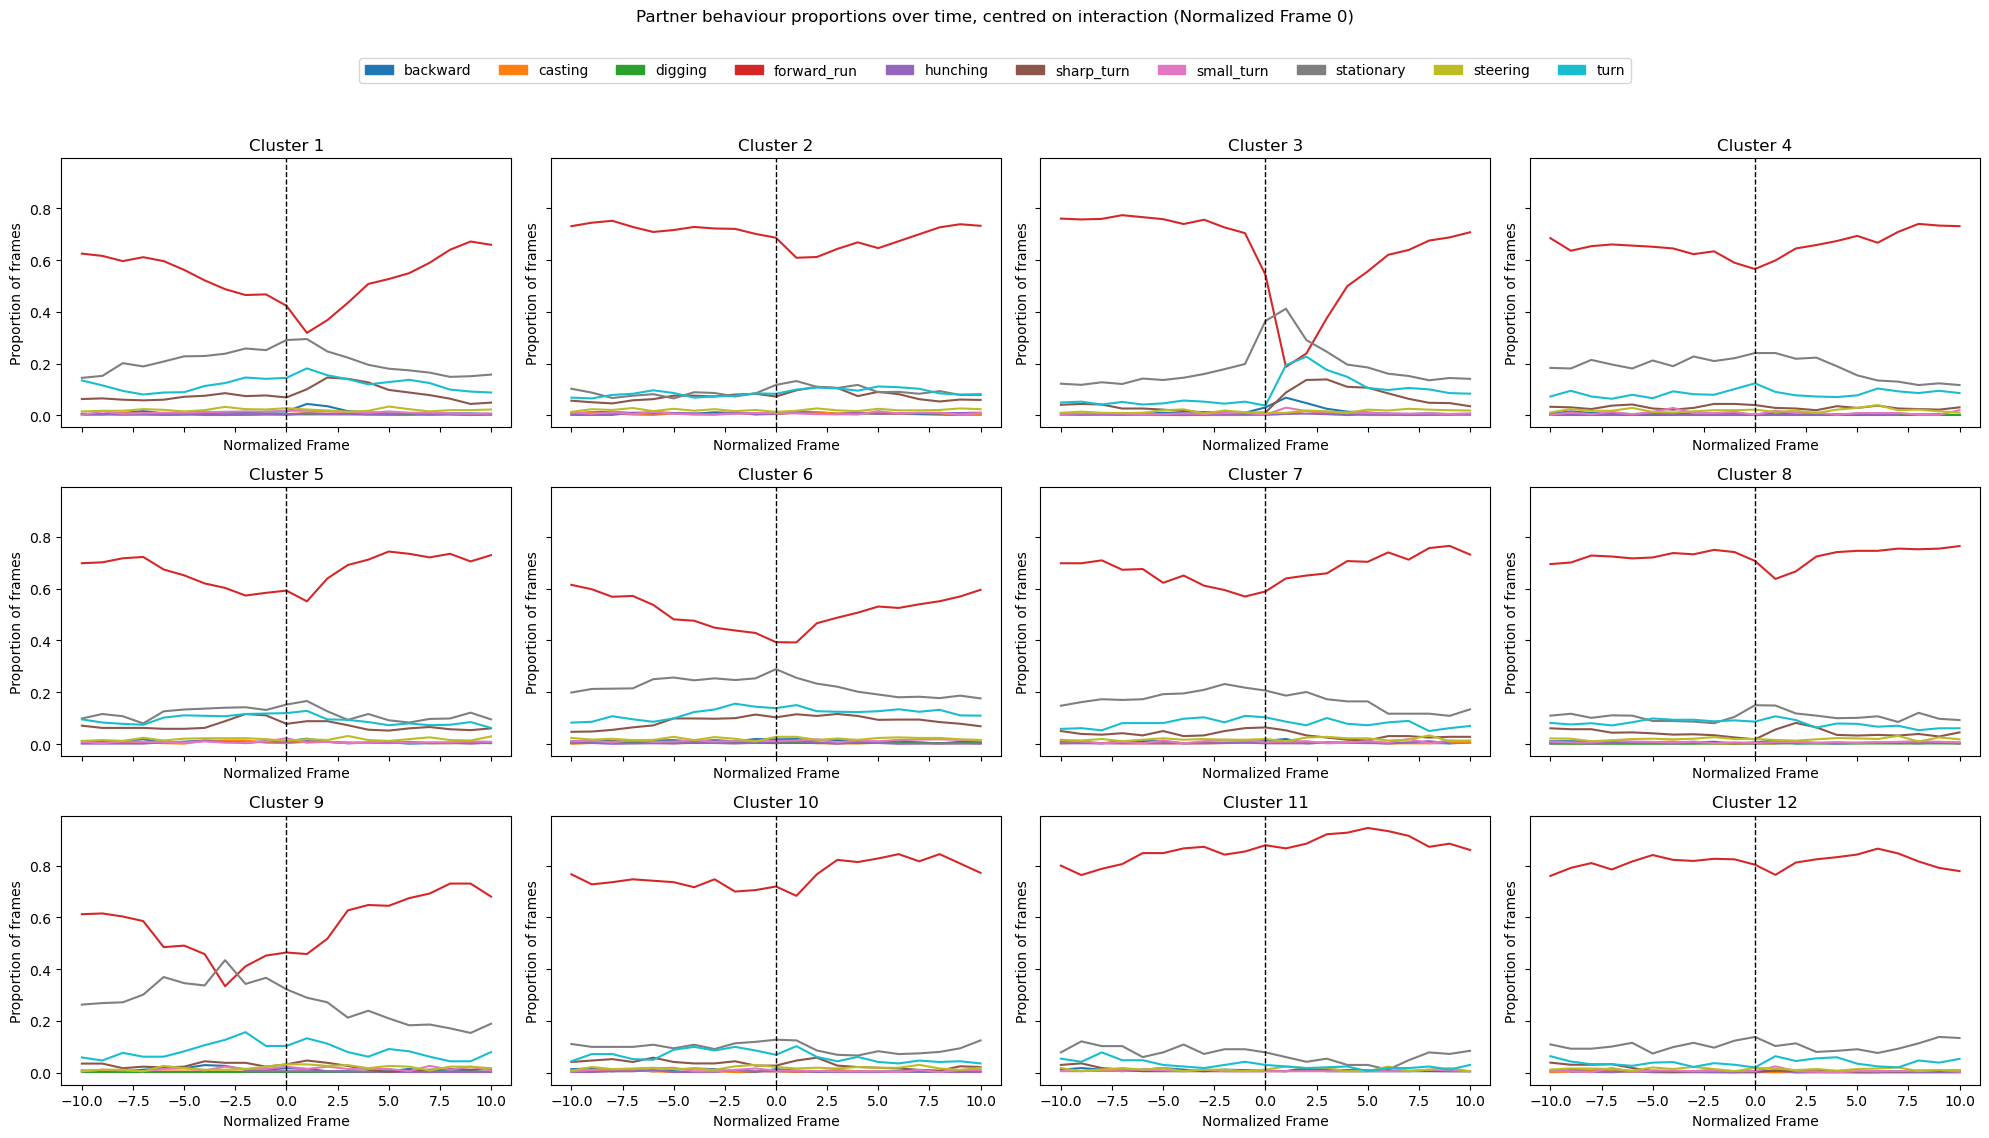

In [3]:
# === Behaviour proportion across Normalized Frame, per cluster ===

frame_behaviour = (
    partner_tracks.groupby(['Yhat.idt.pca', 'Normalized Frame', 'behaviour'])
    .size()
    .reset_index(name='count')
)
frame_totals = frame_behaviour.groupby(['Yhat.idt.pca', 'Normalized Frame'])['count'].transform('sum')
frame_behaviour['proportion'] = frame_behaviour['count'] / frame_totals

n_clusters = len(clusters)
ncols = 4
nrows = int(np.ceil(n_clusters / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, clust in zip(axes, clusters):
    sub = frame_behaviour[frame_behaviour['Yhat.idt.pca'] == clust]
    for beh in behaviours:
        beh_sub = sub[sub['behaviour'] == beh].sort_values('Normalized Frame')
        if beh_sub.empty:
            continue
        ax.plot(beh_sub['Normalized Frame'], beh_sub['proportion'], label=beh, color=palette[beh])
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Cluster {clust}')
    ax.set_xlabel('Normalized Frame')
    ax.set_ylabel('Proportion of frames')

for ax in axes[n_clusters:]:
    ax.axis('off')

handles = [mpatches.Patch(color=palette[b], label=b) for b in behaviours]
fig.legend(handles=handles, loc='upper center', ncol=len(behaviours), bbox_to_anchor=(0.5, 1.04))
fig.suptitle('Partner behaviour proportions over time, centred on interaction (Normalized Frame 0)', y=1.08)
plt.tight_layout()
plt.show()

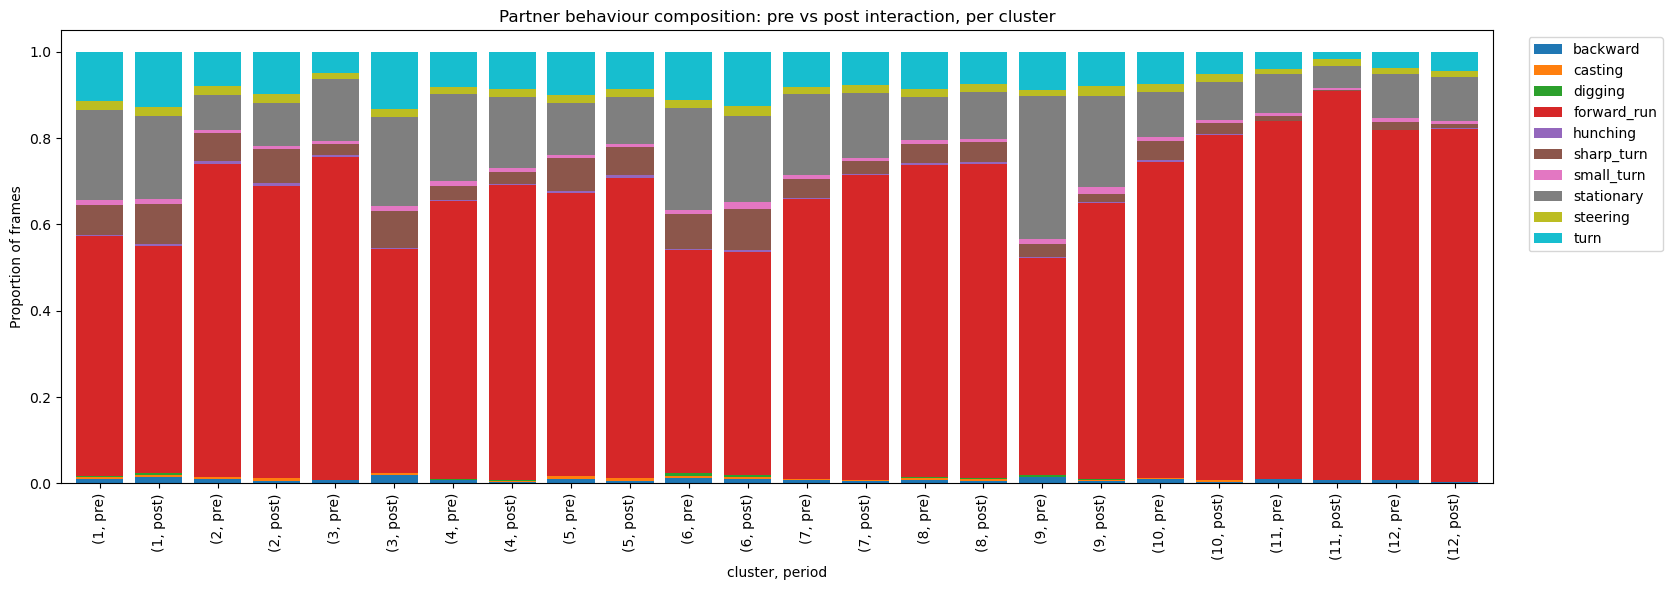

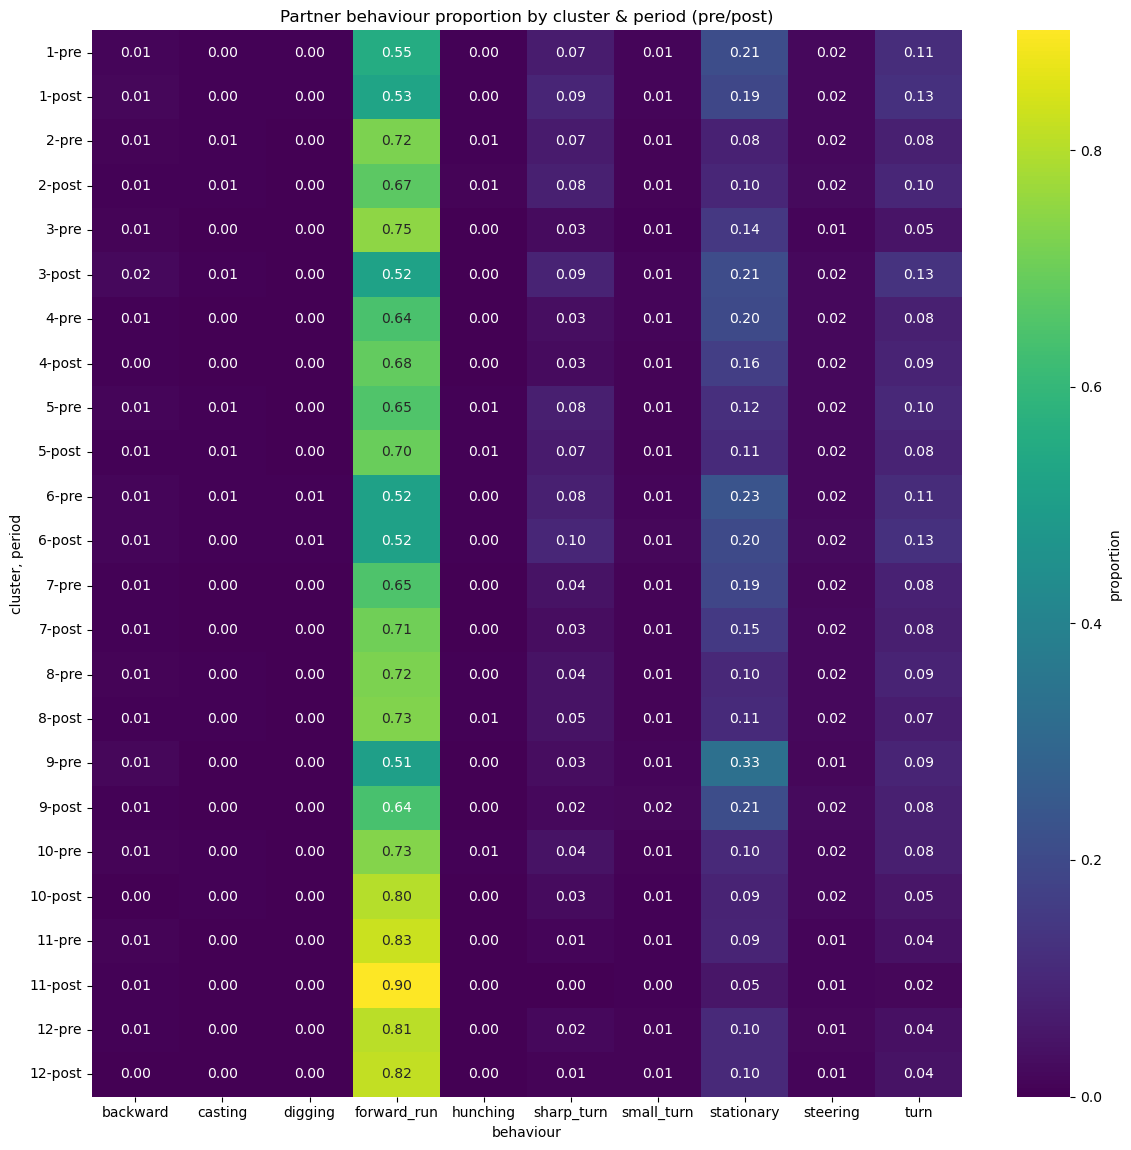

In [4]:
# === Pre vs post behaviour composition per cluster (stacked bar) ===

pre_post = partner_tracks[partner_tracks['period'].isin(['pre', 'post'])]

comp = (
    pre_post.groupby(['Yhat.idt.pca', 'period', 'behaviour'])
    .size()
    .reset_index(name='count')
)
comp['proportion'] = comp['count'] / comp.groupby(['Yhat.idt.pca', 'period'])['count'].transform('sum')

comp_pivot = comp.pivot_table(index=['Yhat.idt.pca', 'period'], columns='behaviour', values='proportion', fill_value=0)
comp_pivot = comp_pivot.reindex(columns=behaviours, fill_value=0)
# order rows as cluster, pre, post
comp_pivot = comp_pivot.reindex(
    pd.MultiIndex.from_product([clusters, ['pre', 'post']], names=['Yhat.idt.pca', 'period'])
)

fig, ax = plt.subplots(figsize=(max(10, n_clusters * 1.4), 6))
comp_pivot.plot(kind='bar', stacked=True, ax=ax, color=[palette[b] for b in behaviours], width=0.8)
ax.set_ylabel('Proportion of frames')
ax.set_xlabel('cluster, period')
ax.set_title('Partner behaviour composition: pre vs post interaction, per cluster')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Same data as a heatmap for quick scanning ===
plt.figure(figsize=(len(behaviours) * 1.2, len(comp_pivot) * 0.4 + 2))
sns.heatmap(comp_pivot, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'proportion'})
plt.title('Partner behaviour proportion by cluster & period (pre/post)')
plt.xlabel('behaviour')
plt.ylabel('cluster, period')
plt.tight_layout()
plt.show()

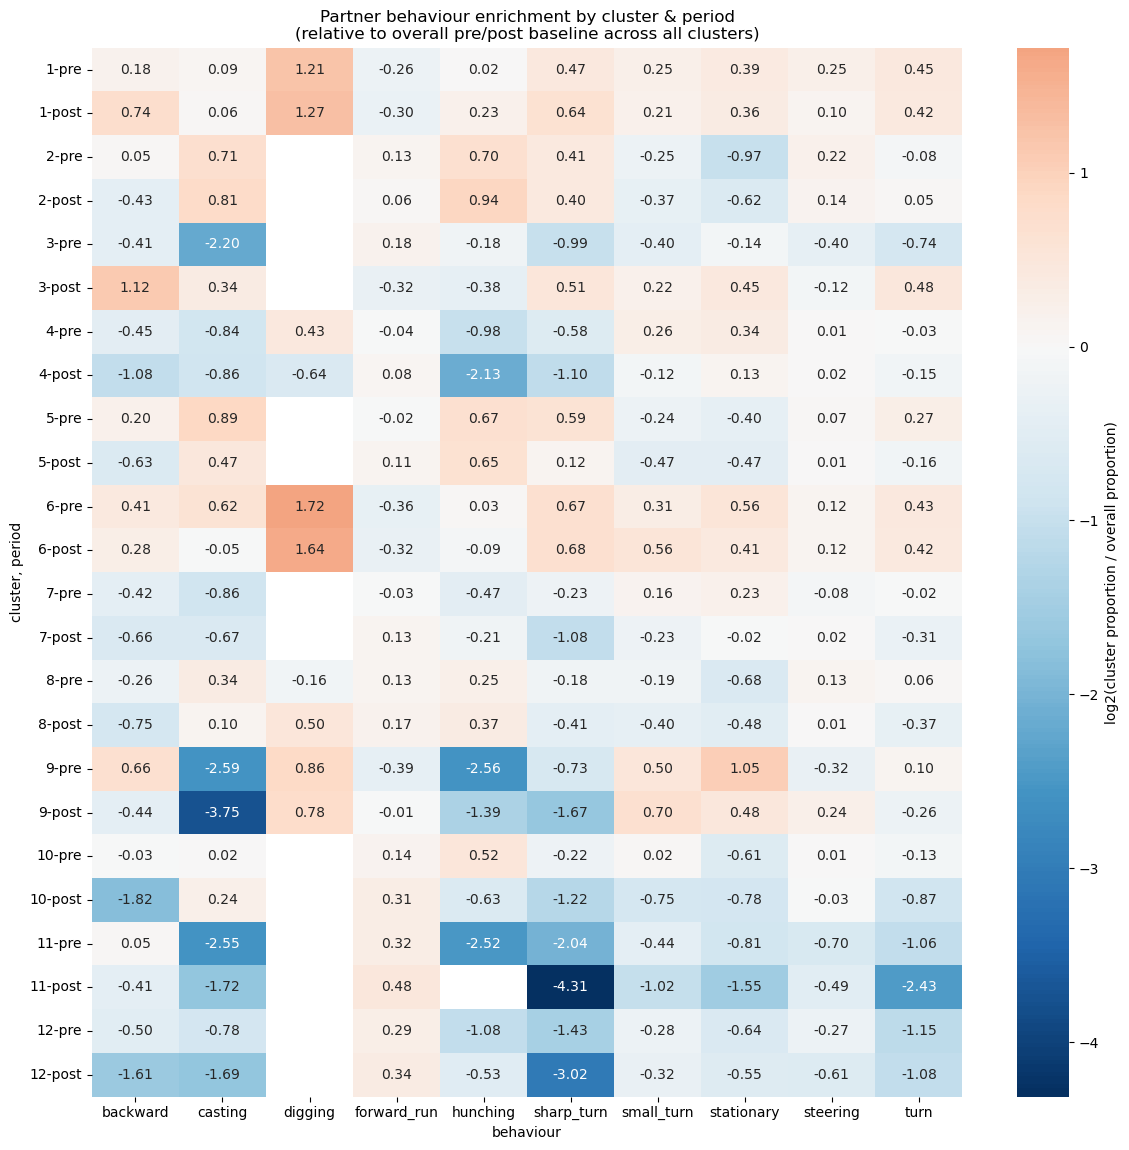

,cluster,chi2,dof,p_value,n_pre,n_post
2,3,1225.393426,8,3.125446e-259,9080,9080
8,9,174.655555,9,6.606489e-33,3380,3380
9,10,67.049169,8,1.895854e-11,3600,3600
5,6,57.095943,9,4.844194e-09,9300,9300
1,2,51.899168,8,1.760266e-08,6720,6720
0,1,53.708808,9,2.144352e-08,7940,7940
10,11,49.068727,8,6.167807e-08,1650,1650
6,7,37.732502,8,8.435027e-06,3580,3580
11,12,36.514822,8,1.413089e-05,4840,4840
4,5,31.638218,8,1.081105e-04,5770,5770


In [5]:
# === Behaviour enrichment per cluster (relative to overall baseline) ===
# log2(cluster proportion / overall proportion) for each behaviour, within each period.
# >0 => behaviour is over-represented in that cluster relative to the average interaction; <0 => under-represented.

overall = (
    pre_post.groupby(['period', 'behaviour'])
    .size()
    .reset_index(name='count')
)
overall['proportion'] = overall['count'] / overall.groupby('period')['count'].transform('sum')
overall_lookup = overall.set_index(['period', 'behaviour'])['proportion']

enrich = comp.copy()
enrich['overall_proportion'] = enrich.set_index(['period', 'behaviour']).index.map(overall_lookup)
enrich['log2_enrichment'] = np.log2(
    (enrich['proportion'] + 1e-6) / (enrich['overall_proportion'] + 1e-6)
)

enrich_pivot = enrich.pivot_table(
    index=['Yhat.idt.pca', 'period'], columns='behaviour', values='log2_enrichment'
).reindex(columns=behaviours)
enrich_pivot = enrich_pivot.reindex(
    pd.MultiIndex.from_product([clusters, ['pre', 'post']], names=['Yhat.idt.pca', 'period'])
)

plt.figure(figsize=(len(behaviours) * 1.2, len(enrich_pivot) * 0.4 + 2))
sns.heatmap(enrich_pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'log2(cluster proportion / overall proportion)'})
plt.title('Partner behaviour enrichment by cluster & period\n(relative to overall pre/post baseline across all clusters)')
plt.xlabel('behaviour')
plt.ylabel('cluster, period')
plt.tight_layout()
plt.show()

# === Chi-square test: does the partner's pre vs post behaviour distribution differ within each cluster? ===
from scipy.stats import chi2_contingency

results = []
for clust in clusters:
    ct = pd.crosstab(
        pre_post.loc[pre_post['Yhat.idt.pca'] == clust, 'period'],
        pre_post.loc[pre_post['Yhat.idt.pca'] == clust, 'behaviour']
    )
    ct = ct.loc[:, (ct.sum(axis=0) > 0)]
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2, p, dof, _ = chi2_contingency(ct)
    results.append({'cluster': clust, 'chi2': chi2, 'dof': dof, 'p_value': p, 'n_pre': ct.loc['pre'].sum() if 'pre' in ct.index else 0, 'n_post': ct.loc['post'].sum() if 'post' in ct.index else 0})

chi2_results = pd.DataFrame(results).sort_values('p_value')
chi2_results